In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/bagheri939/water-potability-csv/water_potability.csv


<div dir="rtl" style="text-align:right"> <h1> بخش اول: پیش پردازش و تحلیل اکتشافی داده ها (EDA) </h1> </div>

<div dir="rtl" style="text-align:right"> <strong>۱. وارد کردن کتابخانه ها</strong></div>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

<div dir="rtl" style="text-align:right"> <strong>۲. خواندن مجموعه داده </strong></div>

In [3]:
df = pd.read_csv("/kaggle/input/datasets/bagheri939/water-potability-csv/water_potability.csv")

<div dir="rtl" style="text-align:right"> 
<strong>۳. مشاهده اولیه داده ها </strong></div>
<div dir="rtl" style="text-align:right"> 
در این مرحله ابعاد مجموعه داده، نوع هر ویژگی و آمار اولیه شامل میانگین، انحراف معیار، کمینه، بیشینه و چارک های مختلف بررسی شد. این اطلاعات دید اولیه مناسبی از ساختار داده ها ارائه میکند. 
</div>

In [4]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [5]:
df.tail()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1
3275,7.874671,195.102299,17404.177061,7.509306,NaN,327.459760,16.140368,78.698446,2.309149,1


In [6]:
df.shape

(3276, 10)

In [7]:
df.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [9]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


<div dir="rtl" style="text-align:right"> <strong> ۴. بررسی داده های گمشده    </strong></div>

<div dir="rtl" style="text-align:right"> مشاهده میشود برخی ویژگی ها دارای مقادیر گمشده هستند. وجود داده های گمشده میتواند باعث کاهش عملکرد مدل شود؛ بنابراین قبل از آموزش مدل باید این مقادیر مدیریت شوند. </div>

In [10]:
df.isnull().sum()
##مشاهده درصد داده های گمشده 
missing = df.isnull().sum()/len(df)*100
print(missing)

ph                 14.987790
Hardness            0.000000
Solids              0.000000
Chloramines         0.000000
Sulfate            23.840049
Conductivity        0.000000
Organic_carbon      0.000000
Trihalomethanes     4.945055
Turbidity           0.000000
Potability          0.000000
dtype: float64


<div dir="rtl" style="text-align:right"> <strong>  ۵. بررسی داده های تکراری   </strong></div>
<div dir="rtl" style="text-align:right"> وجود داده های تکراری میتواند باعث ایجاد سوگیری در مدل شود. بنابراین در صورت وجود، رکوردهای تکراری حذف می‌شوند. اینجا مشاهده می‌شود که داده تکراری وجود ندارد، بنابرین چیزی حذف نمی‌شود. </div>

In [11]:
print(df.duplicated().sum())
df = df.drop_duplicates()

0


<div dir="rtl" style="text-align:right"> <strong> ۶. رسم Histogram   </strong></div>
<div dir="rtl" style="text-align:right"> هیستوگرام توزیع هر ویژگی را نمایش میدهد. از طریق این نمودار میتوان تشخیص داد که داده ها نرمال هستند یا خیر، دارای چولگی هستند یا چند قله دارند. </div>

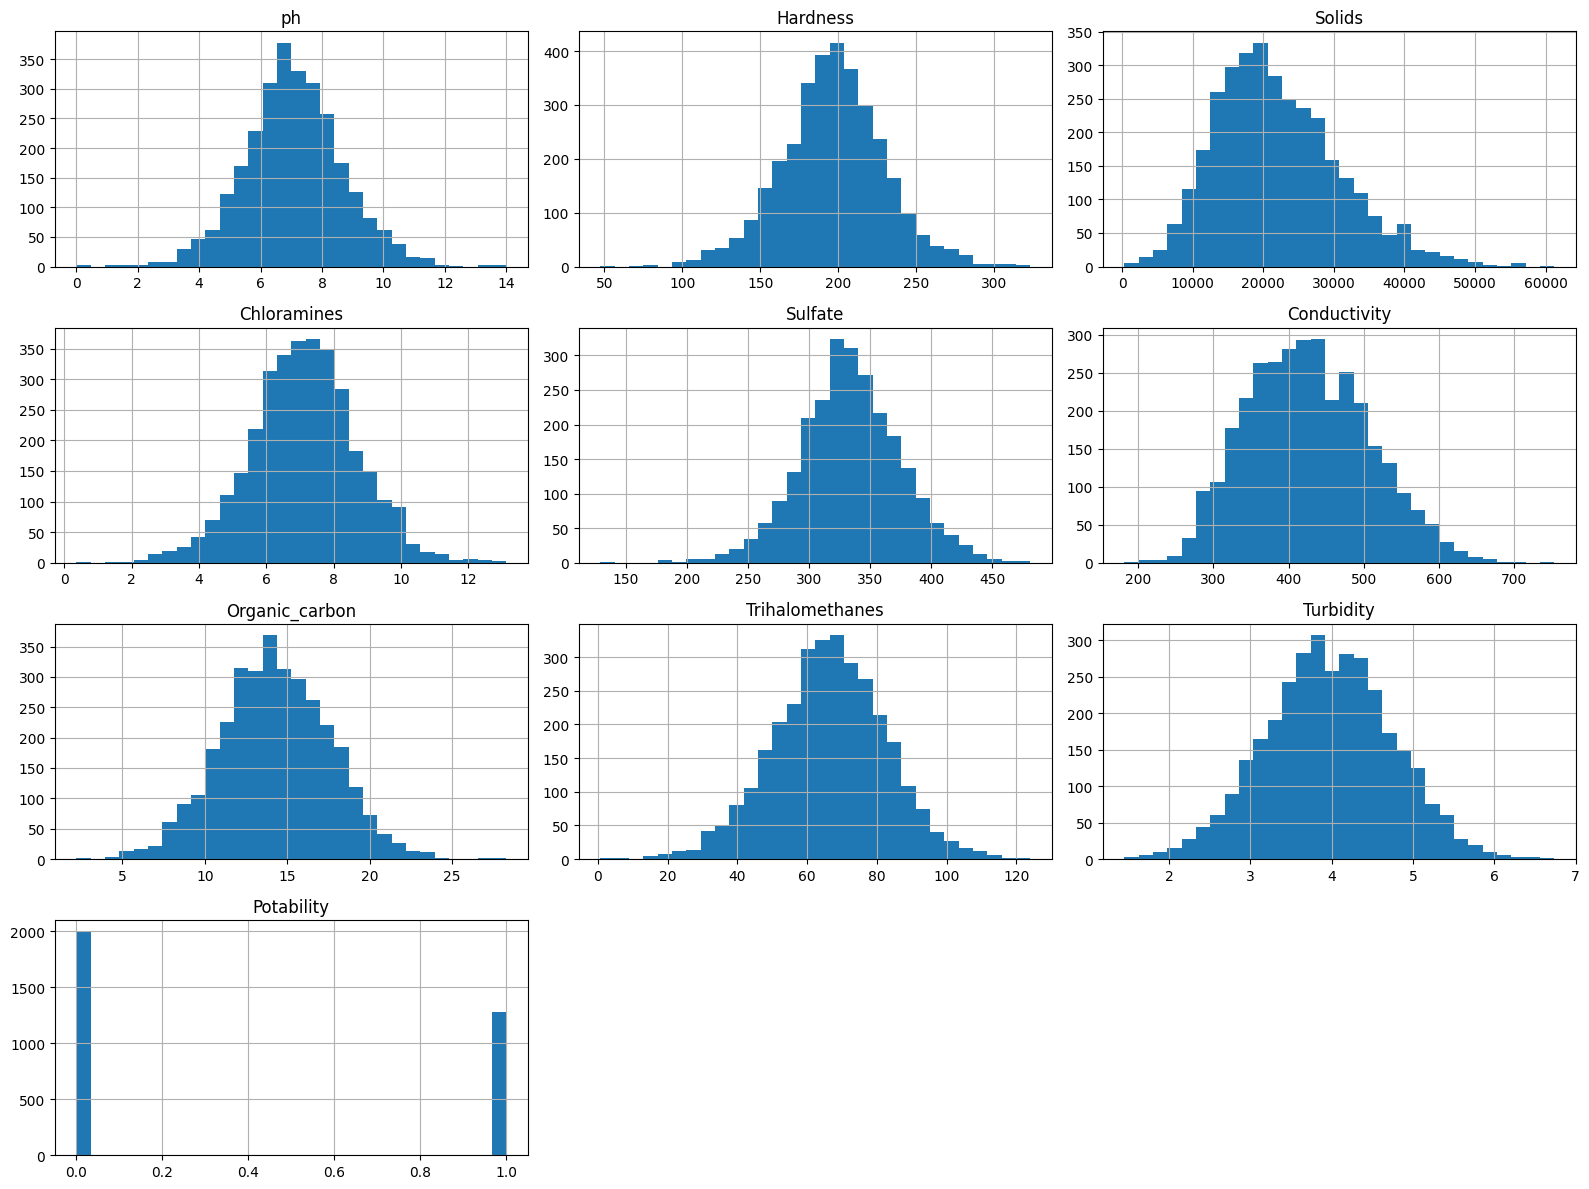

In [12]:
df.hist(figsize=(16,12), bins=30)

plt.tight_layout()
plt.show()